In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import scanpy as sc

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.preprocessing as preprocessing
from constants import ModalityType, STPreprocessingParams

## Constants Definition

In [2]:
PATH = "/staging/leuven/stg_00077/projects/jelle/lipogrid/pilot/MALDI_MSI/d_lipogrid"
PLOT_PATH = os.path.join(PATH, "plots", "preprocessing")
MODALITY_NAME = "Xenium"
MODALITY_TYPE = ModalityType.ST

sc.settings.figdir = PLOT_PATH

## Spatial Transcriptomics Dataset preparation and processing

In [39]:
preprocessing_settings = {
   STPreprocessingParams.MIN_COUNT_PER_SPOT: None,
   STPreprocessingParams.MAX_COUNT_PER_SPOT: None,
   STPreprocessingParams.MIN_GENES_PER_SPOT: None,
   STPreprocessingParams.MAX_GENES_PER_SPOT: None,
   STPreprocessingParams.MIN_SPOTS_PER_GENE: None,
   STPreprocessingParams.MIN_COUNT_SPOTS_RATIO_PER_GENE: None,
   STPreprocessingParams.TOTAL_COUNTS_NORMALIZE: True,
   STPreprocessingParams.LOG1P_TRANSFORM: True,
   STPreprocessingParams.FORCE_RECOMPUTING: True 
}

In [40]:
processed_st = preprocessing.preprocess_modality(
    path=PATH,
    modality_type=ModalityType.ST,
    modality_name=MODALITY_NAME,
    preprocessing_settings=preprocessing_settings,
)

1/2 - Processing Spatial Transcriptomic Samples
Preprocessing sample 20250606_RUN01_01


/staging/leuven/stg_00077/projects/Lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


Preprocessing sample 20250606_RUN01_02


/staging/leuven/stg_00077/projects/Lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


Preprocessing sample 20251119_RUN02_01


/staging/leuven/stg_00077/projects/Lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


Preprocessing sample 20251205_RUN03_01


/staging/leuven/stg_00077/projects/Lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


2/2 - Generating combined Spatial Transcriptomic dataset
Unfiltered genes in combined dataset: 541


/staging/leuven/stg_00077/projects/Lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


## Dataset Visualization

In [41]:
st_dataset = sc.read_h5ad(processed_st['merged'])

In [42]:
print(f"ST dataset has {st_dataset.n_obs} spots and {st_dataset.n_vars} genes.")
print(f"Dataset contains {st_dataset.obs['sample_id'].nunique()} samples.")

ST dataset has 89514 spots and 541 genes.
Dataset contains 4 samples.


In [19]:
# Compute PCA and UMAP visualizations
sc.pp.pca(st_dataset, n_comps=50)
sc.pp.neighbors(st_dataset)
sc.tl.umap(st_dataset)

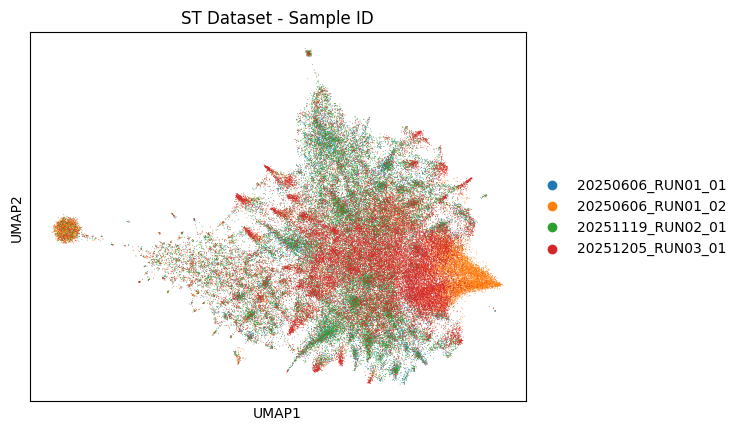

In [20]:
sc.pl.umap(st_dataset, color=['sample_id'], title="ST Dataset - Sample ID", save="_st_dataset_sample_id.png")

In [43]:
st_dataset

AnnData object with n_obs × n_vars = 89514 × 541
    obs: 'image_label', 'cell_label', 'center_row', 'center_col', 'Area', 'bbox', 'equivalent_diameter', 'orientation', 'MajorAxisLength', 'MinorAxisLength', 'Perimeter', 'cell_neighborhood', 'cells', 'gRNA', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample_id'
    uns: 'log1p'
    layers: 'raw'

In [7]:
# Fix format for Focus

files = [
    "20250606_RUN01_01/Xenium/xenium_david_1_with_grna_132649.h5ad",
    "20250606_RUN01_02/Xenium/xenium_david_2_with_grna_132650.h5ad",
    "20251119_RUN02_01/Xenium/xenium_david_3_with_grna_164421.h5ad",
    "20251205_RUN03_01/Xenium/xenium_david_4_with_grna_164422.h5ad"
]

raster_size = 0
for file in files:
    full_path = os.path.join(PATH, file)
    dataset = sc.read_h5ad(full_path)
    raster_size += np.mean(dataset.obs["equivalent_diameter"].to_numpy())

raster_size /= len(files)

raster_size = int(np.round(raster_size) / 10)

print(f"Using raster size: {raster_size}")

for file in files:
    full_path = os.path.join(PATH, file)
    dataset = sc.read_h5ad(full_path)

    # Create obsm spatial
    dataset.obsm['spatial'] = dataset.obs[['center_row', 'center_col']].to_numpy()
    dataset.uns['raster_size'] = [raster_size, raster_size]

    # Save the updated dataset
    dataset.write_h5ad(full_path)

Using raster size: 10
